In [1]:
%cd ..

/mnt/aimm/scratch/querfurth/code/virtues-world/virtues


In [2]:
import os
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

from omegaconf import OmegaConf
from safetensors import safe_open


from virtues.modules.multiplex_virtues import MultiplexVirtues
from virtues.modules.segmentation.unet import VirtuesFeatureUNet
from virtues.data.multiplex_dataset import MultiplexDataset
from virtues.utils.utils import load_marker_embeddings
from virtues.utils.segmentation import tiled_logits_inference, remove_small_cells, assign_cell_types


from instanseg.utils.loss.instanseg_loss import InstanSeg as InstanceProcessor

### Pan-optic cell segmentation
In this notebook, we demonstrate how to use VirTues in combination with a U-Net style segmentation head to do both instance and phenotype-segmentation in one shot.

#### 1. Model Initialization

To get started, instantiate the VirTues model and load its pretrained weights.

A default configuration file is provided at `configs/base_config.yaml`. This file contains all parameters required for the released VirTues model.

In addition, you must specify a directory containing the embeddings for all markers used. Each embedding should be saved as a `.pt` file, named according to its respective UniProt ID.

In [3]:
conf = OmegaConf.load('configs/base_config.yaml')

PATH_MARKER_EMBEDDINGS = 'assets/example_dataset/marker_embeddings'

In [4]:
marker_embeddings = load_marker_embeddings(PATH_MARKER_EMBEDDINGS)

model = MultiplexVirtues(
    use_default_config = False,
    custom_config = None,
    prior_bias_embeddings=marker_embeddings,
    prior_bias_embedding_type='esm',
    prior_bias_embedding_fusion_type='add',
    patch_size=conf.model.patch_size,
    model_dim=conf.model.model_dim,
    feedforward_dim=conf.model.feedforward_dim,
    encoder_pattern=conf.model.encoder_pattern,
    num_encoder_heads=conf.model.num_encoder_heads,
    decoder_pattern=conf.model.decoder_pattern,
    num_decoder_heads=conf.model.num_decoder_heads,
    num_hidden_layers=conf.model.num_decoder_hidden_layers,
    positional_embedding_type=conf.model.positional_embedding_type,
    dropout=conf.model.dropout,
    group_layers=conf.model.group_layers,
    norm_after_encoder_decoder=conf.model.norm_after_encoder_decoder,
    verbose=False
)

We provide model weights of our pretrained VirTues instance on Hugging Face Hub. These can be downloaded via `hf_hub_download` as follows.

In [5]:
# CACHE_DIR = 'assets/checkpoints'
# hf_hub_download(repo_id='bunnelab/virtues', filename='model.safetensors', local_dir=CACHE_DIR)
CACHE_DIR = "/mnt/aimm/scratch/shr/mmvirtues/outputs/May5-sp23-tmglobalstd/checkpoints_new_architecture/checkpoint-190050"

weights = {}
with safe_open(os.path.join(CACHE_DIR, 'model.safetensors'), framework="pt", device='cpu') as f:
    for k in f.keys():
        weights[k] = f.get_tensor(k)
model.load_state_dict(weights)

model = model.cuda()
model = model.eval()

Now, we initialize and load the VirTues segmentation head

In [35]:
instance_processor = InstanceProcessor(
    device="cuda",
    n_sigma=2,
    cells_and_nuclei=False,
    window_size=64,
)

segmentation_head = VirtuesFeatureUNet(
    virtues_model=model,
    dim_out=5,
    num_celltypes=9,
).to("cuda")
segmentation_model = instance_processor.initialize_pixel_classifier(segmentation_head, MLP_width=5)

In [36]:
segmentation_head_weight = "/mnt/aimm/scratch/shr/mmvirtues/outputs/May5-sp23-tmglobalstd/segmentation-head/virtues-seg-noNK-May5-sp23-no_cords24/model_weights.pth"

In [37]:
checkpoint = torch.load(segmentation_head_weight, map_location="cuda")

state = checkpoint["model_state_dict"]
if any(k.startswith("module.") for k in state):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

# pixel classifier weights:
state_pixel_classifier = {k.replace("pixel_classifier.", "", 1): v for k, v in state.items() if k.startswith("pixel_classifier.")}
segmentation_model.pixel_classifier.load_state_dict(state_pixel_classifier)

# instance segmentation branch weights:
state_instance_segmentation_head = {k.replace("decoder.", "", 1): v for k, v in state.items() if k.startswith("decoder.")}
segmentation_model.decoder.load_state_dict(state_instance_segmentation_head)

# phenotype segmentation branch weights:
state_phenotype_segmentation_head = {k.replace("decoder_phenotypes.", "", 1): v for k, v in state.items() if k.startswith("decoder_phenotypes.")}
segmentation_model.decoder_phenotypes.load_state_dict(state_phenotype_segmentation_head)

segmentation_model.eval()

VirtuesFeatureUNet(
  (virtues_model): MultiplexVirtues(
    (encoder): MultiplexVirtuesEncoder(
      (patch_encoder): Linear(in_features=64, out_features=512, bias=True)
      (prior_embedding_encoder): Linear(in_features=640, out_features=512, bias=True)
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (encoder): ModuleList(
        (0): ChannelAttentionEncoderBlock(
          (encoder_layer): TransformerEncoderBlock(
            (multi_head_attention): MHAwithPosEmb(
              (W_q): Linear(in_features=512, out_features=512, bias=True)
              (W_k): Linear(in_features=512, out_features=512, bias=True)
              (W_v): Linear(in_features=512, out_features=512, bias=True)
              (W_o): Linear(in_features=512, out_features=512, bias=True)
              (pos_emb): RotaryPositionalEmbedding2D(
                (rope1d): RotaryPositionalEmbedding1D()
              )
            )
            (feedforward): Sequential(
              (0):

Now we load a dataset and retrieve a single tile

In [19]:
ds_conf = OmegaConf.load('configs/datasets/example_config.yaml')['datasets']['example_dataset']

dataset = MultiplexDataset(
            tissue_dir=ds_conf.tissue_dir,
            crop_dir=ds_conf.crop_dir,
            mask_dir=ds_conf.mask_dir,
            tissue_index=ds_conf.tissue_index,
            crop_index=ds_conf.crop_index,
            channels_file=ds_conf.channels_file,
            quantiles_file=ds_conf.quantiles_file,
            means_file=ds_conf.means_file,
            stds_file=ds_conf.stds_file,
            marker_embedding_dir=PATH_MARKER_EMBEDDINGS,
            split='test',
            crop_size=conf.data.crop_size,
            patch_size=conf.model.patch_size,
            masking_ratio=conf.data.masking_ratio,
            channel_fraction=conf.data.channel_fraction,
    )

In [20]:
tid = 'cords24_ocmzljpb_1'
x = dataset.get_tissue(tid, preprocess=True)
midxs = dataset.get_marker_indices().cuda()
crop = x[:, 10:138, 10:138]

/mnt/aimm/scratch/querfurth/code/virtues-world/virtues/virtues/data/multiplex_dataset.py:148: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.marker_indices, dtype=torch.long)


In [21]:
logits = segmentation_model([crop.cuda()], [midxs.cuda()])[0]

Now, we can postprocess the instance prediction componentes using the instanseg postprocessor. Also, we do not want the phenotype segmentation head to predict "background" or the "unknown" class. <br>
The phenotype mapping is as follows: 
```python
{0: 'None',
 1: 'B cell',
 2: 'CD4 T cell',
 3: 'CD8 T cell',
 4: 'Fibroblasts /Stroma',
 5: 'Myeloid',
 6: 'Tumor',
 7: 'Unknown',
 8: 'Vessel / Endo.'}
 ```

In [22]:
cell_type_mapping = {0: 'None', 1: 'B cell', 2: 'CD4 T cell', 3: 'CD8 T cell', 4: 'Fibroblasts /Stroma', 5: 'Myeloid', 6: 'Tumor', 7: 'Unknown', 8: 'Vessel / Endo.'}

inst_logits = logits[: int(segmentation_model.dim_out)]
pred_instance = instance_processor.postprocessing(inst_logits.to("cuda"), window_size=64, cleanup_fragments=True)[0]
pred_instance = pred_instance.cpu()
pred_instance = remove_small_cells(pred_instance, min_cell_size=15)
semantic_logits = logits[segmentation_model.dim_out:, :, :]
semantic_logits[[0, 7], :, :] = float("-inf")
semantic_pred = torch.argmax(semantic_logits, dim=0).cpu()
semantic_pred = assign_cell_types(pred_instance, semantic_pred)

In [31]:
segmentation_model

VirtuesFeatureUNet(
  (virtues_model): MultiplexVirtues(
    (encoder): MultiplexVirtuesEncoder(
      (patch_encoder): Linear(in_features=64, out_features=512, bias=True)
      (prior_embedding_encoder): Linear(in_features=640, out_features=512, bias=True)
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (encoder): ModuleList(
        (0): ChannelAttentionEncoderBlock(
          (encoder_layer): TransformerEncoderBlock(
            (multi_head_attention): MHAwithPosEmb(
              (W_q): Linear(in_features=512, out_features=512, bias=True)
              (W_k): Linear(in_features=512, out_features=512, bias=True)
              (W_v): Linear(in_features=512, out_features=512, bias=True)
              (W_o): Linear(in_features=512, out_features=512, bias=True)
              (pos_emb): RotaryPositionalEmbedding2D(
                (rope1d): RotaryPositionalEmbedding1D()
              )
            )
            (feedforward): Sequential(
              (0):

Let's take a the instance and phenotype cell segmentations:

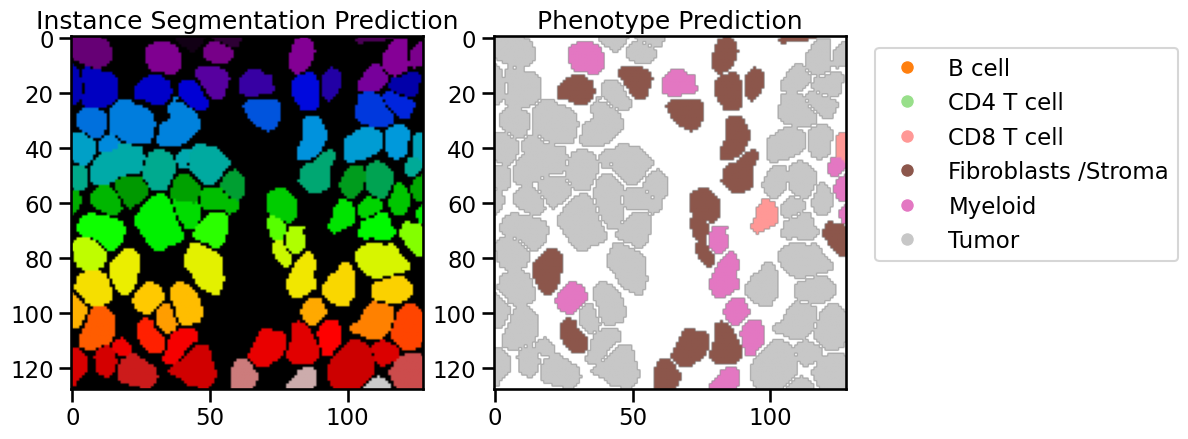

In [27]:
semantic_pred_vis = np.copy(semantic_pred).astype(np.float16)
semantic_pred_vis[semantic_pred_vis == 0] = np.nan # set background to nan for visualization

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(pred_instance, cmap="nipy_spectral")
ax[0].set_title("Instance Segmentation Prediction")
ax[1].imshow(semantic_pred_vis, cmap="tab20", vmin=0, vmax=8)
ax[1].set_title("Phenotype Prediction")

# add legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'{cell_type_mapping[i]}', markerfacecolor=plt.cm.tab20(i / 8), markersize=10) for i in range(1, semantic_pred.max() + 1)]
ax[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In the following, we show how to predict cell instances and phenotypes on a larger image or core.

In [60]:
logits = tiled_logits_inference(
    segmentation_model=segmentation_model,
    tissue_image=x,
    channels=midxs,
    tile=128,
    ovlp=32,
    bs=4
)

inst_logits = logits[: int(segmentation_model.dim_out)]
pred_instance = instance_processor.postprocessing(inst_logits.to("cuda"), window_size=64, cleanup_fragments=True)[0]
pred_instance = pred_instance.cpu()
pred_instance = remove_small_cells(pred_instance, min_cell_size=15)
semantic_logits = logits[segmentation_model.dim_out:, :, :]
semantic_logits[[0, 7], :, :] = float("-inf")
semantic_pred = torch.argmax(semantic_logits, dim=0).cpu()
semantic_pred = assign_cell_types(pred_instance, semantic_pred)

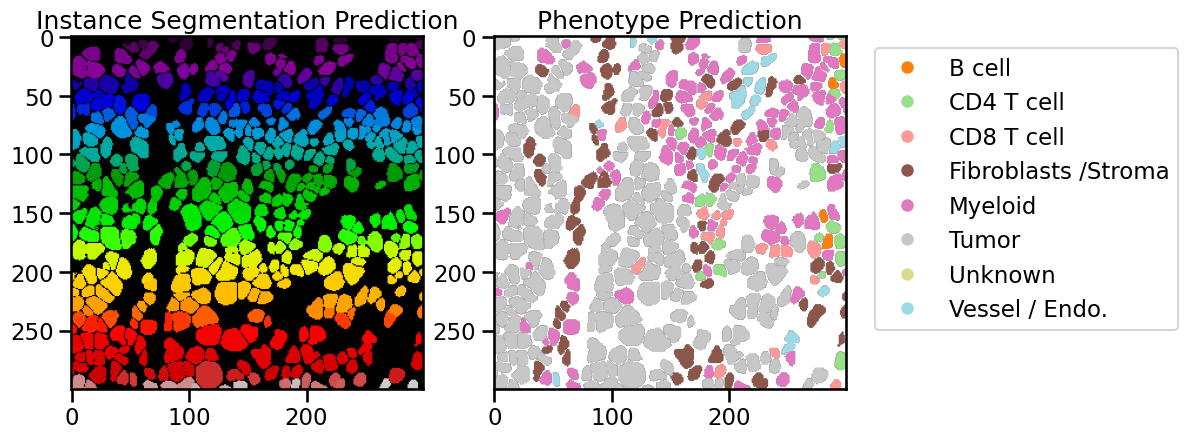

In [61]:
semantic_pred_vis = np.copy(semantic_pred).astype(np.float16)
semantic_pred_vis[semantic_pred_vis == 0] = np.nan # set background to nan for visualization

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(pred_instance, cmap="nipy_spectral")
ax[0].set_title("Instance Segmentation Prediction")
ax[1].imshow(semantic_pred_vis, cmap="tab20", vmin=0, vmax=8)
ax[1].set_title("Phenotype Prediction")

# add legend
handles = [plt.Line2D([0], [0], marker='o', color='w', label=f'{cell_type_mapping[i]}', markerfacecolor=plt.cm.tab20(i / 8), markersize=10) for i in range(1, semantic_pred.max() + 1)]
ax[1].legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()